In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as ticker
from statsmodels.stats.multitest import multipletests

In [10]:
genome=[30427671,19698289,23459830,18585056,26975502]
space=2000000
chr1=30427671 / 2 
chr2=30427671 + 19698289 / 2 + space
chr3=30427671 + 19698289 + 23459830 / 2 + space * 2
chr4=30427671 + 19698289 + 23459830 + 18585056 / 2 + space * 3
chr5=30427671 + 19698289 + 23459830 + 18585056 + 26975502 / 2 + space * 4

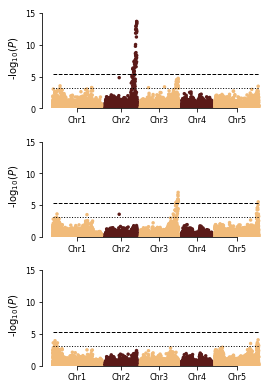

In [15]:
def parse(assoc):
    df = pd.read_table(assoc)
    df['P'] = -(np.log10(df['p_lrt']))
    df['P_bi'] = (np.log10(df['p_lrt']))
    space=2000000
    df['position'] = np.select([df['chr'] == 1, 
                                                df['chr'] == 2, 
                                                df['chr'] == 3, 
                                                df['chr'] == 4, 
                                                df['chr'] == 5],
                        [df['ps'], 
                        df['ps'] + 30427671 + space, 
                        df['ps'] + 30427671 + 19698289 + space * 2,
                        df['ps'] + 30427671 + 19698289 + 23459830 + space * 3,
                        df['ps'] + 30427671 + 19698289 + 23459830 + 18585056 + space * 4])
    
    return(df)



def plotting(dataframe,idx):
    sns.scatterplot(x='position',
                    y='P',
                    data=dataframe,
                    hue='chr',
                    palette=['#F1BB7A','#5B1A18','#F1BB7A','#5B1A18','#F1BB7A'],
                    marker='o',
                    s=12,
                    linewidth=0,
                    legend=False,
                    ax=ax[idx])
    ax[idx].set_xticks([chr1,chr2,chr3,chr4,chr5]),
    ax[idx].tick_params(axis='both', which='major', labelsize=8)
    ax[idx].set_xticklabels(["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
#     ax[idx].set_title('w. Chr5:' + str(position))
    ax[idx].set_xlabel('')
    ax[idx].set_ylabel('-log$_{10}$($\itP$)',fontsize=10)
    ax[idx].hlines(y=-np.log10(0.05/len(dataframe)),
                 xmin=min(dataframe['position']),
                 xmax=max(dataframe['position']),
                 color='0',
                 linestyle='--',
                 linewidth=1,
                 zorder=1)
    ax[idx].hlines(y=classic[classic["Significant"] == True]['P'].min(),
                 xmin=min(classic['position']),
                 xmax=max(classic['position']),
                 color='0',
                 linestyle=':',
                 linewidth=1,
    #              alpha=0.4,
                 zorder=1)
    ax[idx].yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax[idx].set_ylim(0,16)
#     ax[idx].set_ylim(0,)
    
    
classic=parse('DH_leaf_B_blues.assoc.txt.gz')
chr2_19379353=parse('DH_leaf_B_blues_chr2_19379353.assoc.txt.gz')
chr2_19379353_chr3_23254270=parse('DH_leaf_B_blues_chr2_19379353_chr3_23254270.assoc.txt.gz')

rejected, pvals_corrected, _, _ = multipletests(classic['p_lrt'], alpha=0.1, method='fdr_bh')
classic["Significant"] = rejected
classic["FDR_corrected_pval"] = pvals_corrected

cm = 1/2.54
fig , ax = plt.subplots(3,1,figsize=(10*cm,14*cm))
plotting(classic,0)
# ax[0].set_title('all SNPs')
plotting(chr2_19379353,1)
plotting(chr2_19379353_chr3_23254270,2)

# ax[0].set_ylim(0,11)
# ax[1].set_ylim(0,8)
# ax[1].set_title('w. $\itBOR2$_S313G')

# ax.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# plt.xlabel('Chromosome',fontsize=10)
# plt.ylim(0,20)
plt.ylabel('-log$_{10}$($\itP$)',fontsize=10)
# plt.xticks([chr1,chr2,chr3,chr4,chr5],["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"])
sns.despine(trim=True)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.savefig("Fig4b.png", format="png",bbox_inches="tight",facecolor="w",dpi=600)

In [16]:
classic.loc[classic['chr'] == 2].sort_values(by='P', ascending=False)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position,Significant,FDR_corrected_pval
4904,2,2:19379353,19379353,6,C,T,0.127,17.412410,1.995594,1.159034,1.205355,2.777530e-15,2.202128e-14,2.210107e-08,13.657157,-13.657157,51807024,True,1.297115e-10
4909,2,2:19393400,19393400,7,T,G,0.122,17.987470,2.043593,0.997426,1.037649,1.748202e-15,2.304324e-14,6.614015e-08,13.637456,-13.637456,51821071,True,1.297115e-10
4911,2,2:19408000,19408000,1,G,C,0.136,16.888460,1.988174,1.573840,1.635437,1.115050e-14,3.582179e-14,1.243991e-08,13.445853,-13.445853,51835671,True,1.297115e-10
4912,2,2:19415508,19415508,2,A,G,0.124,17.499210,2.096847,2.091441,2.205126,2.713352e-14,4.441415e-14,1.780010e-09,13.352479,-13.352479,51843179,True,1.297115e-10
4889,2,2:19285777,19285777,0,G,T,0.135,16.657860,1.979733,1.527700,1.589747,1.801766e-14,6.328456e-14,3.815301e-08,13.198702,-13.198702,51713448,True,1.478580e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3266,2,2:3688949,3688949,4,A,G,0.074,-0.194834,3.934909,4.827170,100000.000000,9.605694e-01,9.916310e-01,9.916437e-01,0.003650,-0.003650,36116620,False,9.937184e-01
4451,2,2:14947107,14947107,4,T,G,0.457,0.142128,2.210887,4.772173,100000.000000,9.488206e-01,9.917866e-01,9.917990e-01,0.003582,-0.003582,47374778,False,9.937431e-01
3231,2,2:3031406,3031406,3,A,C,0.073,-0.198533,3.941173,4.827806,100000.000000,9.598853e-01,9.920508e-01,9.920628e-01,0.003466,-0.003466,35459077,False,9.939226e-01
4562,2,2:16175666,16175666,11,A,G,0.167,-0.003283,2.315795,4.650562,100000.000000,9.988707e-01,9.944829e-01,9.944913e-01,0.002403,-0.002403,48603337,False,9.955249e-01


In [6]:
chr2_19379353.loc[chr2_19379353['chr'] == 3].sort_values(by='P', ascending=False)

,chr,rs,ps,n_miss,allele1,allele0,af,beta,se,l_remle,l_mle,p_wald,p_lrt,p_score,P,P_bi,position
7411,3,3:23254270,23254270,3,G,A,0.059,12.355300,2.344342,1.595265,1.716609,5.612086e-07,4.821110e-07,0.000005,6.316853,-6.316853,77380230
7407,3,3:23197891,23197891,2,T,C,0.070,10.140300,2.173822,1.188779,1.255511,7.667902e-06,5.901300e-06,0.000028,5.229052,-5.229052,77323851
7398,3,3:23128482,23128482,1,G,A,0.073,9.651705,2.153459,1.113023,1.174479,1.622851e-05,1.252470e-05,0.000048,4.902233,-4.902233,77254442
7256,3,3:21656886,21656886,8,G,A,0.057,10.209090,2.433607,1.004984,1.055515,5.059678e-05,3.982296e-05,0.000115,4.399866,-4.399866,75782846
7380,3,3:23044100,23044100,4,C,T,0.063,9.578995,2.338230,1.023821,1.076706,7.385819e-05,5.873464e-05,0.000157,4.231106,-4.231106,77170060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6629,3,3:14700371,14700371,0,T,C,0.141,-0.008913,2.079100,1.017352,0.999935,9.965860e-01,9.980387e-01,0.998049,0.000853,-0.000853,68826331
5828,3,3:8942217,8942217,7,A,T,0.073,-0.008946,2.648711,0.993430,0.999536,9.973103e-01,9.981325e-01,0.998153,0.000812,-0.000812,63068177
5114,3,3:1141551,1141551,2,A,G,0.151,0.001556,1.916006,0.996578,0.999825,9.993532e-01,9.991484e-01,0.999151,0.000370,-0.000370,55267511
6995,3,3:18572851,18572851,6,C,T,0.080,-0.020946,2.259687,0.959528,0.999702,9.926187e-01,9.995314e-01,0.999539,0.000204,-0.000204,72698811
